<a href="https://colab.research.google.com/github/MuhammadAqsandy/Practical-Statistics-for-Data-Scientist-Books/blob/main/PracticalStatisticsChapter2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 2 – Data & Sampling Distributions

## 📖 Summary
Chapter 2 covers the statistical theory of **sampling** and **probability distributions**. It bridges descriptive statistics (Chapter 1) with inferential statistics by explaining how samples relate to populations, and how uncertainty is quantified through distributions.

### Key Topics Covered:
1. **Random Sampling & Bias** – simple random sampling, stratified, selection bias
2. **Sampling Distribution of a Statistic** – distribution of the sample mean
3. **The Bootstrap** – resampling to estimate variability
4. **Confidence Intervals** – quantifying estimation uncertainty
5. **Normal Distribution** – bell curve, Z-scores, QQ-plots
6. **Long-Tailed Distributions** – heavy tails, fat tails
7. **Binomial Distribution** – successes in n trials
8. **Poisson & Exponential Distributions** – count & time-between-events


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print("Libraries loaded ✓")


Libraries loaded ✓


## 2. Random Sampling & Sampling Distribution

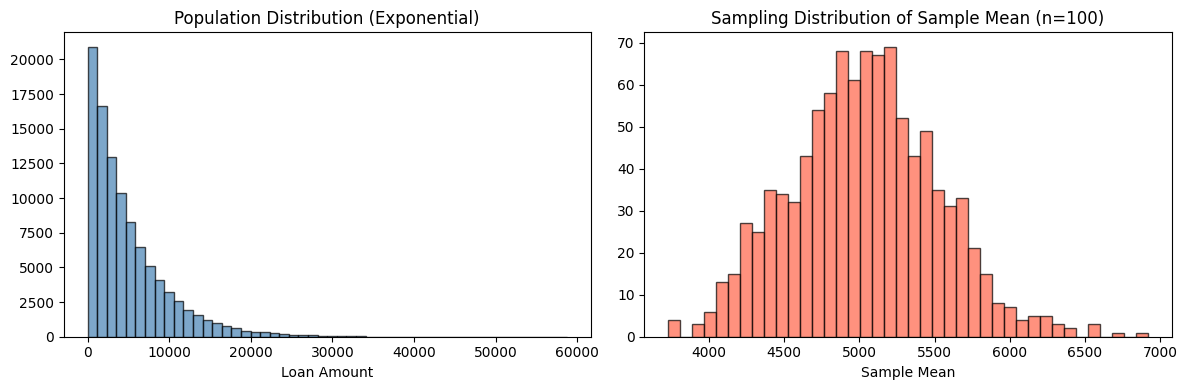

Population mean:         4979.85
Mean of sample means:    5032.18
Std of sample means (SE):491.00
SE = σ/√n =              496.48


In [2]:
# Population: simulated loan amounts
population = np.random.exponential(scale=5000, size=100_000)

# Draw many samples and compute their means
sample_means = [np.random.choice(population, size=100).mean() for _ in range(1000)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(population, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Population Distribution (Exponential)')
axes[0].set_xlabel('Loan Amount')

axes[1].hist(sample_means, bins=40, color='tomato', edgecolor='black', alpha=0.7)
axes[1].set_title('Sampling Distribution of Sample Mean (n=100)')
axes[1].set_xlabel('Sample Mean')

plt.tight_layout()
plt.savefig('ch2_sampling_dist.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"Population mean:         {population.mean():.2f}")
print(f"Mean of sample means:    {np.mean(sample_means):.2f}")
print(f"Std of sample means (SE):{np.std(sample_means):.2f}")
print(f"SE = σ/√n =              {population.std()/np.sqrt(100):.2f}")


### 📚 Theory: Central Limit Theorem (CLT)
The **CLT** states: regardless of population shape, the sampling distribution of the sample mean approaches **Normal** as sample size $n$ grows.

$$SE = \frac{\sigma}{\sqrt{n}}$$

The **Standard Error (SE)** measures how much the sample mean varies from sample to sample. A larger $n$ → smaller SE → more precise estimates.


## 3. Bootstrap Resampling

Sample median:       3274.27
Bootstrap median:    3220.58
Bootstrap SE:        437.30
95% CI:              [2479.47, 4032.35]


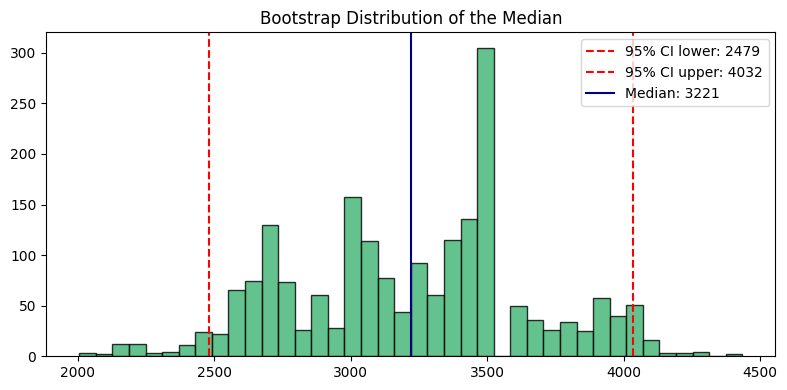

In [3]:
# Bootstrap estimate of the median
sample = np.random.choice(population, size=200, replace=False)

bootstrap_medians = []
for _ in range(2000):
    boot_sample = np.random.choice(sample, size=len(sample), replace=True)
    bootstrap_medians.append(np.median(boot_sample))

boot_median = np.mean(bootstrap_medians)
boot_se = np.std(bootstrap_medians)
ci_low, ci_high = np.percentile(bootstrap_medians, [2.5, 97.5])

print(f"Sample median:       {np.median(sample):.2f}")
print(f"Bootstrap median:    {boot_median:.2f}")
print(f"Bootstrap SE:        {boot_se:.2f}")
print(f"95% CI:              [{ci_low:.2f}, {ci_high:.2f}]")

plt.figure(figsize=(8, 4))
plt.hist(bootstrap_medians, bins=40, color='mediumseagreen', edgecolor='black', alpha=0.8)
plt.axvline(ci_low, color='red', linestyle='--', label=f'95% CI lower: {ci_low:.0f}')
plt.axvline(ci_high, color='red', linestyle='--', label=f'95% CI upper: {ci_high:.0f}')
plt.axvline(boot_median, color='navy', linestyle='-', label=f'Median: {boot_median:.0f}')
plt.title('Bootstrap Distribution of the Median')
plt.legend()
plt.tight_layout()
plt.savefig('ch2_bootstrap.png', dpi=100, bbox_inches='tight')
plt.show()


### 📚 Theory: Bootstrap
The **bootstrap** resamples *with replacement* from the observed data thousands of times to empirically estimate the sampling distribution of *any* statistic — without needing to know the population distribution.

Key uses: estimating SE, building confidence intervals, hypothesis testing.


## 4. Normal Distribution & Z-scores

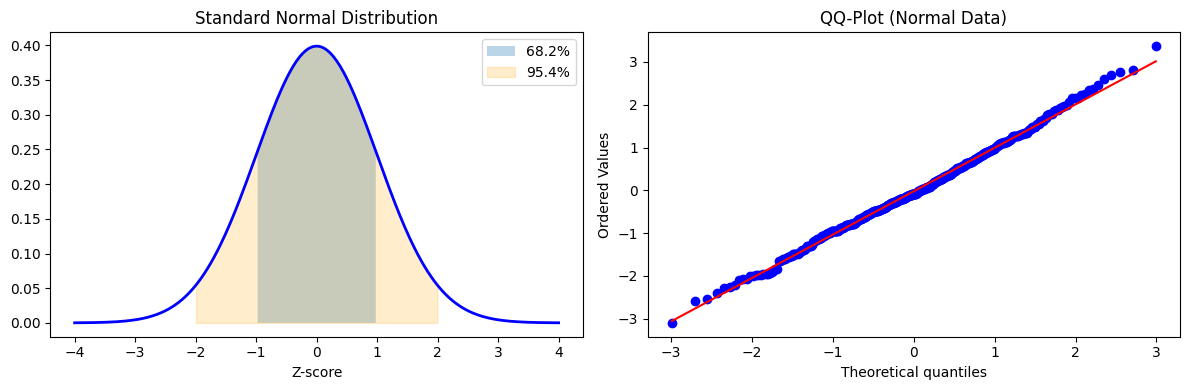

Z-score of 75 (μ=65, σ=10): 1.00
Percentile: 84.1%


In [4]:
x = np.linspace(-4, 4, 300)
y = stats.norm.pdf(x)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Normal PDF with shading
axes[0].plot(x, y, 'b-', linewidth=2)
axes[0].fill_between(x, y, where=(x >= -1) & (x <= 1), alpha=0.3, label='68.2%')
axes[0].fill_between(x, y, where=(x >= -2) & (x <= 2), alpha=0.2, color='orange', label='95.4%')
axes[0].set_title('Standard Normal Distribution')
axes[0].set_xlabel('Z-score')
axes[0].legend()

# QQ-plot of normal data
normal_data = np.random.normal(0, 1, 500)
stats.probplot(normal_data, plot=axes[1])
axes[1].set_title('QQ-Plot (Normal Data)')

plt.tight_layout()
plt.savefig('ch2_normal.png', dpi=100, bbox_inches='tight')
plt.show()

# Z-score example
val, mu, sigma = 75, 65, 10
z = (val - mu) / sigma
print(f"Z-score of {val} (μ={mu}, σ={sigma}): {z:.2f}")
print(f"Percentile: {stats.norm.cdf(z)*100:.1f}%")


## 5. Binomial Distribution

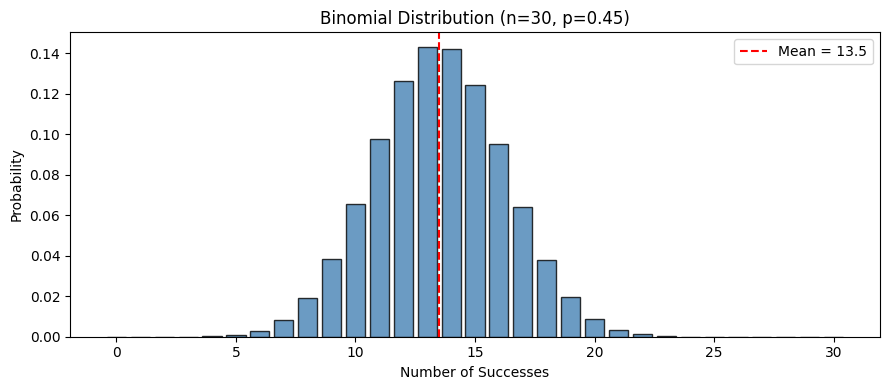

Mean:     13.5
Variance: 7.425
P(X=15):  0.1242
P(X≤15):  0.7691


In [5]:
n, p = 30, 0.45   # 30 trials, 45% success rate
x_vals = np.arange(0, n+1)
pmf = stats.binom.pmf(x_vals, n, p)

plt.figure(figsize=(9, 4))
plt.bar(x_vals, pmf, color='steelblue', edgecolor='black', alpha=0.8)
plt.axvline(n*p, color='red', linestyle='--', label=f'Mean = {n*p}')
plt.xlabel('Number of Successes')
plt.ylabel('Probability')
plt.title(f'Binomial Distribution (n={n}, p={p})')
plt.legend()
plt.tight_layout()
plt.savefig('ch2_binomial.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"Mean:     {n*p}")
print(f"Variance: {n*p*(1-p):.3f}")
print(f"P(X=15):  {stats.binom.pmf(15, n, p):.4f}")
print(f"P(X≤15):  {stats.binom.cdf(15, n, p):.4f}")


## 6. Poisson & Exponential Distribution

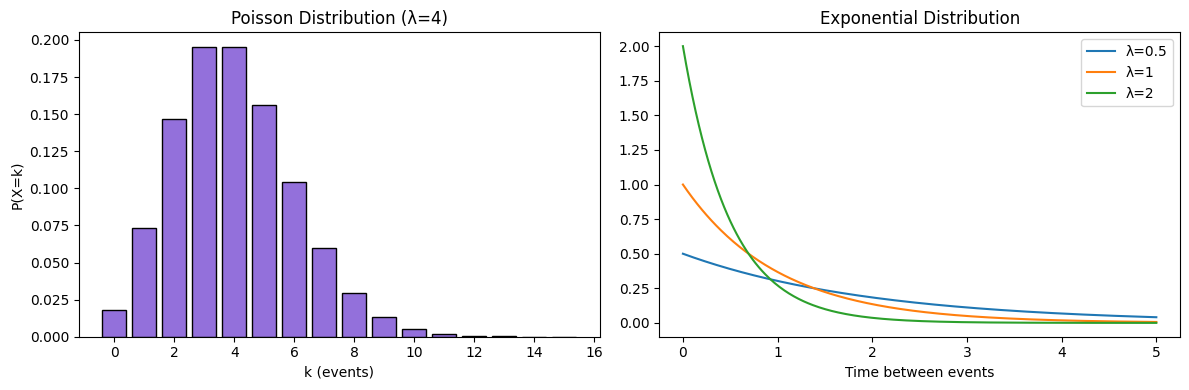

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Poisson
lam = 4
k_vals = np.arange(0, 16)
axes[0].bar(k_vals, stats.poisson.pmf(k_vals, lam), color='mediumpurple', edgecolor='black')
axes[0].set_title(f'Poisson Distribution (λ={lam})')
axes[0].set_xlabel('k (events)')
axes[0].set_ylabel('P(X=k)')

# Exponential
x = np.linspace(0, 5, 300)
for rate in [0.5, 1, 2]:
    axes[1].plot(x, stats.expon.pdf(x, scale=1/rate), label=f'λ={rate}')
axes[1].set_title('Exponential Distribution')
axes[1].set_xlabel('Time between events')
axes[1].legend()

plt.tight_layout()
plt.savefig('ch2_poisson_exp.png', dpi=100, bbox_inches='tight')
plt.show()


## ✅ Chapter 2 Summary

| Distribution | Use Case | Parameters |
|---|---|---|
| Normal | Continuous symmetric data | μ, σ |
| Binomial | Count of successes in n trials | n, p |
| Poisson | Count of events in fixed interval | λ |
| Exponential | Time between events | λ |

- **Bootstrap** enables inference without distributional assumptions.
- **CLT** guarantees that sample means are normally distributed for large n.
- **Standard Error** = $\sigma / \sqrt{n}$ — not the same as standard deviation.
